# Import libraries and config

In [1]:
import sys
sys.path.insert(0, '../') # Trick to import code from parent folder
import cmip6_archive as ca
import xarray as xr
import xesmf as xe
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import colormaps as cmaps
import cartopy.crs as ccrs
import regionmask
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import FuncFormatter, PercentFormatter
import matplotlib.colorizer as mcolorizer
import matplotlib.colors as mcolors

BASELINE_YEARS = slice(1981, 2000)   # matches the 90th-percentile reference period
FUTURE_YEARS = slice(2071, 2100)

# Filepaths of Land Use Harmonization 2 (LUH2) data for each experiment
exp_LUH2path = {
    "historical": "/work10/archive/CMIP6/CMIP-SSPs/LandUse/LUH2_v2h_historical/states_LUH2_v2h_historical_850_2015.nc",
    "ssp126": "/work10/archive/CMIP6/CMIP-SSPs/LandUse/LUH2_v2f_future_states/multiple-states_input4MIPs_landState_ScenarioMIP_UofMD-IMAGE-ssp126-2-1-f_gn_2015-2100.nc",
    "ssp245": "/work10/archive/CMIP6/CMIP-SSPs/LandUse/LUH2_v2f_future_states/multiple-states_input4MIPs_landState_ScenarioMIP_UofMD-MESSAGE-ssp245-2-1-f_gn_2015-2100.nc",
    "ssp370": "/work10/archive/CMIP6/CMIP-SSPs/LandUse/LUH2_v2f_future_states/multiple-states_input4MIPs_landState_ScenarioMIP_UofMD-AIM-ssp370-2-1-f_gn_2015-2100.nc",
    "ssp585": "/work10/archive/CMIP6/CMIP-SSPs/LandUse/LUH2_v2f_future_states/multiple-states_input4MIPs_landState_ScenarioMIP_UofMD-MAGPIE-ssp585-2-1-f_gn_2015-2100.nc",
}

# Directory where we'll save crop exposure data
outdir = Path("/work10/archive/CMIP6/CMIP-SSPs/crop_exposure_new")

# Auxiliary functions

In [2]:
def get_crop_data(exp, exp_to_path = exp_LUH2path, chunks=None) -> xr.DataArray:
    """Returns a DataArray with the fraction of each grid cell occupied by
     cropland in the given experiment. The data comes from Land Use Harmonization 2 (LUH2), see
      https://luh.umd.edu/ or Hurtt et al. 2020 fo further info."""

    path = exp_to_path[exp]
    ds = xr.open_dataset(path, decode_times=False, chunks=chunks)

    ds = ds.rename({'time': 'year'})

    if exp == "historical":
        # historical land use data covers 850 to 2015, so year 0 = 850 and year 1166 = 2015
        ds['year'] = ds.year.astype(int) + 850
        ds = ds.sel(year=slice('1981', '2014')) # we only care about this period
    else:
        # ssp land use data covers 2015 to 2100, so year 0 = 2015 and year 86 = 2100
        ds['year'] = ds.year.astype(int) + 2015


    # Sum all types of crops
    crop_vars = ['c3ann', 'c4ann', 'c3per', 'c4per', 'c3nfx']
    crops = ds[crop_vars].to_dataarray(dim="crop_fraction").sum("crop_fraction")

    return crops

def regrid(ds_in, regrid_to, method="conservative", skipna=False):
    """Convenience function for one-time regridding. Regrids data in `ds_in` to the grid used in `regrid_to`."""
    regridder = xe.Regridder(ds_in, regrid_to, method=method, periodic=True) # When dealing with global grids, we need to set periodic=True, otherwise data along the meridian line will be missing.
    ds_out = regridder(ds_in, skipna=skipna)
    return ds_out

# Common 1º x 1º grid to compute the MME later
common_grid = xr.Dataset({
        "lat": ("lat", np.arange(-89.5, 90.0, 1.0)),
        "lon": ("lon", np.arange(0.5, 360.0, 1.0)),
    })
common_grid

<xarray.Dataset> Size: 4kB
Dimensions:  (lat: 180, lon: 360)
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Data variables:
    *empty*

# Calculate crop exposure anomaly for all models and experiments

In [ ]:
import warnings
# Ignore repeated warnings after the first occurrence
warnings.filterwarnings("once")

def calculate_crop_exposure_anomaly(ref_grid_ds, exp = "ssp126", models = ca.MODELS):
    # The regridding logic is adapted from https://projectpythia.org/cmip6-cookbook/notebooks/example-workflows/xesmf-ohu/
    # Credit goes to R. Abernathey, H. Drake, R. R. Ford, M. Grover, and Project Pythia contributors (2026)

    print(f"[{exp}] Calculating absolute anomaly in crop exposure for {len(models)} models...")
    
    ds_regrid_dict = {}
    success_count = 0
    model_count = 0

    crops = get_crop_data(exp=exp).sel(year=FUTURE_YEARS)
    crops_hist = get_crop_data(exp="historical").sel(year=BASELINE_YEARS)

    for model in models:
        try:
            # 1. Historical baseline (1981-2000 mean of historical simulation)
            metrics_hist = ca.THIRSTWAVE_METRICS_GS_ARCHIVE.open(model=model, exp="historical").sel(year=BASELINE_YEARS)
            crops_hist_regridded = regrid(crops_hist, metrics_hist, method="conservative") # Regrid crop data to match this model's resolution
            exposure_hist = (crops_hist_regridded * metrics_hist.event_count)
            baseline = exposure_hist.mean(dim='year')

            # 2. Exposure at the end of century (2071-2100 mean of this experiment)
            metrics_exp = ca.THIRSTWAVE_METRICS_GS_ARCHIVE.open(model=model, exp=exp).sel(year=FUTURE_YEARS)
            crops_regridded = regrid(crops, metrics_exp, method="conservative")
            exposure_exp = (crops_regridded * metrics_exp.event_count)
            end_of_century = exposure_exp.mean(dim='year')

            # 3. Calculate anomaly
            anomaly = (end_of_century - baseline) # Absolute change

            # 4. Mask out grid cells with < 5% land
            land_area_fraction = ca.LAND_MASKS_ARCHIVE.open(model=model, exp='piControl')['sftlf']
            mask = (land_area_fraction >= 5).values
            anomaly.name = "crop_exposure_anom"
            anomaly = anomaly.where(mask).to_dataset()
            anomaly["mask"] = (('lat', 'lon'), mask) # We add the mask data to the Dataset so the regridding doesn't treat NaNs like regular data (see https://pangeo-xesmf.readthedocs.io/en/latest/notebooks/Masking.html#)

            # 5. Regrid to the common grid
            anomaly_regridded = regrid(anomaly, ref_grid_ds, method="conservative", skipna=True)
            if 'type' in anomaly_regridded.coords:
                anomaly_regridded = anomaly_regridded.drop_vars("type")
        
        except Exception as e:
            raise RuntimeError('Failed to compute anomaly for '+model+': '+str(e))
        
        ds_regrid_dict[model]= anomaly_regridded.crop_exposure_anom
        print(model+' regridded and added to dictionary')
        success_count += 1
        model_count += 1
            
    print('-'*40+'\n| '+str(success_count)+'/'+str(model_count)+' models successfully regridded! |\n'+'-'*40)

    # Dataset with all models (absolute anomaly)
    ds = list(ds_regrid_dict.values())
    coord = list(ds_regrid_dict.keys())
    ds_out_regrid = xr.concat(objs=ds, dim=coord, coords='all').rename({'concat_dim':'model'})

    return ds_out_regrid

crop_exposures = {}
for exp in ["ssp126", "ssp245", "ssp370", "ssp585"]:
    ds_out = calculate_crop_exposure_anomaly(common_grid, exp=exp)
    outpath = outdir / f"{exp}_all_models_crop_exposure_anom.nc"
    ds_out.to_netcdf(outpath)
    crop_exposures[exp] = ds_out
    print(f"Saved {exp} data to {outpath}")

[ssp126] Calculating absolute anomaly in crop exposure for 8 models...


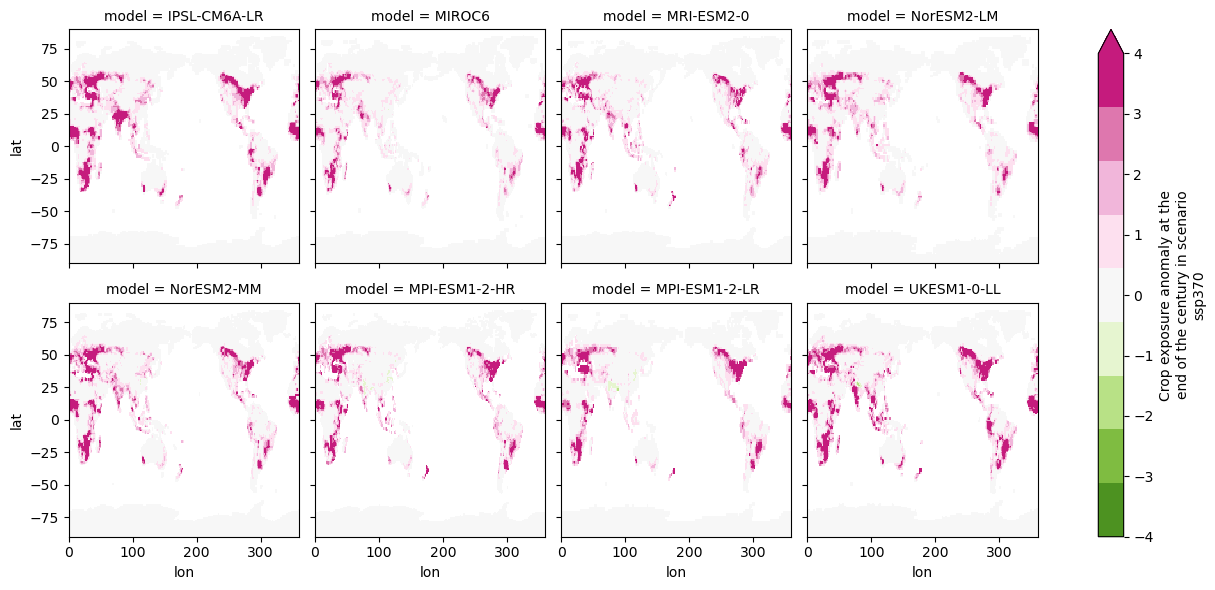

In [ ]:
# Check out individual model results
crop_exposures['ssp370'].plot(col='model', cmap=cmaps.piyg_r, vmax=4, vmin=-4, col_wrap=4)

# Load crop exposure from files
Run this if the previous step was already executed beforehand.

In [3]:
crop_exposures = {}
for exp in ["ssp126", "ssp245", "ssp370", "ssp585"]:
    # Open file (run previous cell if file does not exist)
    inpath = outdir / f"{exp}_all_models_crop_exposure_anom.nc"
    ds_in = xr.open_dataset(inpath)

    # Add metadata
    ds_in['crop_exposure_anom'].attrs['long_name'] = f"Crop exposure anomaly at the end of the century in scenario {exp}"
    ds_in['crop_exposure_anom'].attrs['description'] = f"Calculated as mean crop exposure in {FUTURE_YEARS.start}-{FUTURE_YEARS.stop} of {exp} minus the historical baseline ({BASELINE_YEARS.start}-{BASELINE_YEARS.stop} mean in historical experiment). Calculated for 8 CMIP6 models and regridded to a common 1ºx1º degree common grid."

    # Add to dict
    crop_exposures[exp] = ds_in['crop_exposure_anom']
    print(f"Loaded {exp} data from {inpath}")

Loaded ssp126 data from /work10/archive/CMIP6/CMIP-SSPs/crop_exposure_new/ssp126_all_models_crop_exposure_anom.nc
Loaded ssp245 data from /work10/archive/CMIP6/CMIP-SSPs/crop_exposure_new/ssp245_all_models_crop_exposure_anom.nc
Loaded ssp370 data from /work10/archive/CMIP6/CMIP-SSPs/crop_exposure_new/ssp370_all_models_crop_exposure_anom.nc
Loaded ssp585 data from /work10/archive/CMIP6/CMIP-SSPs/crop_exposure_new/ssp585_all_models_crop_exposure_anom.nc


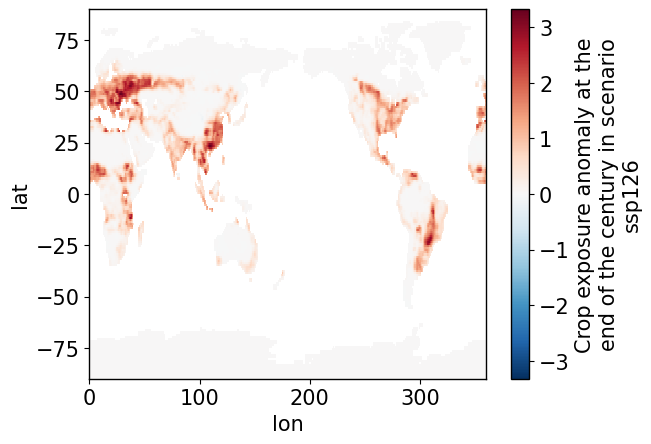

In [11]:
# Take mean across models
mmes = {}
for exp, crop_exposure in crop_exposures.items():
    mmes[exp] = crop_exposures[exp].mean(dim='model', skipna=False)

mmes['ssp126'].plot()

# Plots

## SSP1-2.6: one panel per model

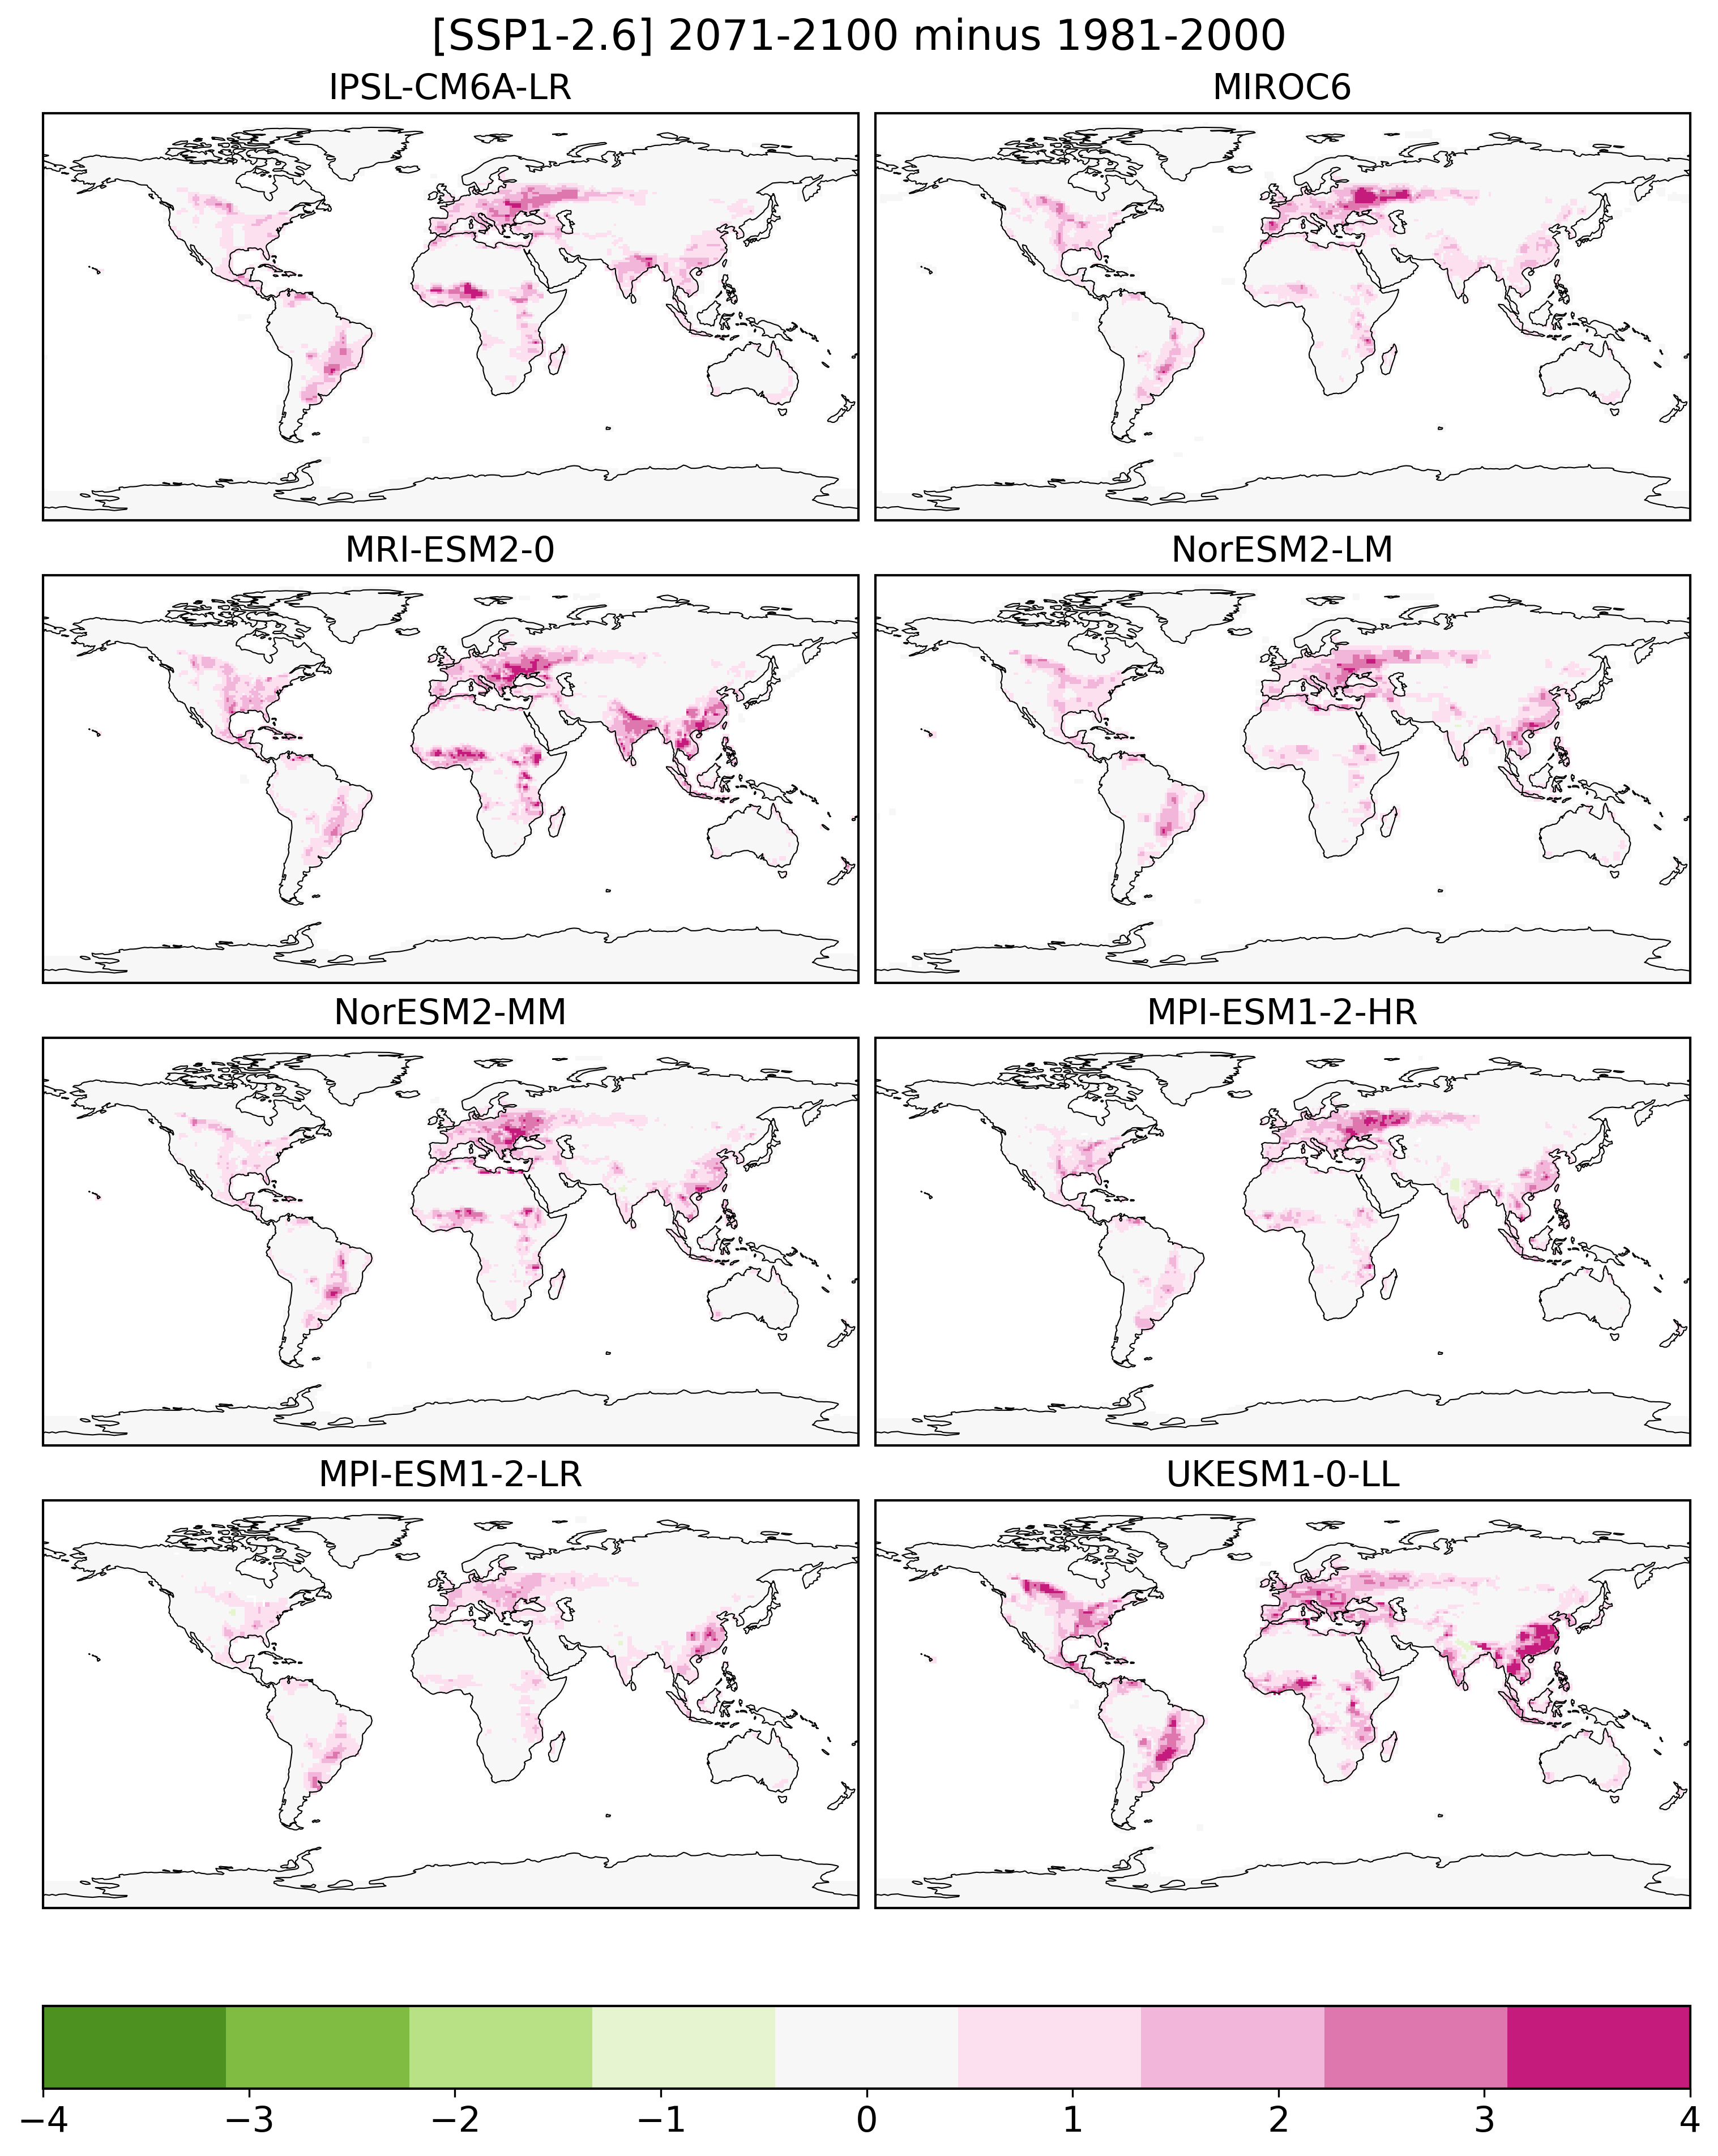

In [12]:
fig, axes = plt.subplots(nrows=4, ncols=2,
                         subplot_kw=dict(projection=ccrs.PlateCarree()),
                         figsize=(10, 13), dpi=300,
                         layout="compressed")
axes = axes.flatten()

for ax in axes:
    ax.coastlines(linewidth=0.5)

images = []
for i, model in enumerate(ca.MODELS):
    im = crop_exposures['ssp126'].sel(model=model).plot(ax=axes[i], cmap=cmaps.piyg_r, vmin=-4, vmax=4, add_colorbar=False)
    images.append(im)
    axes[i].set_title(model, fontsize="medium")

# create a colorizer with a predefined norm to be shared across all images
norm = mcolors.Normalize(vmin=-4, vmax=4)
colorizer = mcolorizer.Colorizer(norm=norm)
fig.colorbar(mappable=images[0], ax=axes, orientation='horizontal', fraction=.1)
fig.suptitle("[SSP1-2.6] 2071-2100 minus 1981-2000")
fig.show()

## MME

In [9]:
def plot_exposure(ds, vmin=-1, vmax=1, cmap=cmaps.piyg_10_r, title="", show_regions = False):
    lons, lats = ds.lon, ds.lat
    data = ds.values

    LINEWIDTH = 1
    plt.rcParams.update({'font.size': 15})
    plt.rcParams['axes.linewidth'] = LINEWIDTH  # Sets default spine linewidth

    fig = plt.figure(figsize=(11, 7.5))
    ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree())

    ax.set_title(title)
    ax.coastlines(linewidth=LINEWIDTH)
    ax.bbox

    im = ax.pcolormesh(
        lons, lats, data,
        cmap=cmap,
        transform=ccrs.PlateCarree(),
        vmin=vmin,
        vmax=vmax,
        shading='nearest'
    )

    ax.set_extent([-180, 180, -65, 90], crs=ccrs.PlateCarree())
    #ax.add_feature(cfeature.OCEAN, color="0.9", zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, color="black")
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, color="gray")

    if show_regions:
        ar6_land = regionmask.defined_regions.ar6.land
        ar6_land.plot(
            ax=ax, label="abbrev", add_ocean=False, add_coastlines=False,
            line_kws=dict(linewidth=0.8, color="black"),
            text_kws=dict(fontsize=7, bbox=dict(pad=0.15, alpha=0)),
        )


    cb = fig.colorbar(im, orientation='horizontal', aspect=30, fraction=0.1, pad=0.03)
    cb.outline.set_color('black')
    cb.outline.set_linewidth(LINEWIDTH)
    plt.tight_layout()
    plt.show()

/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


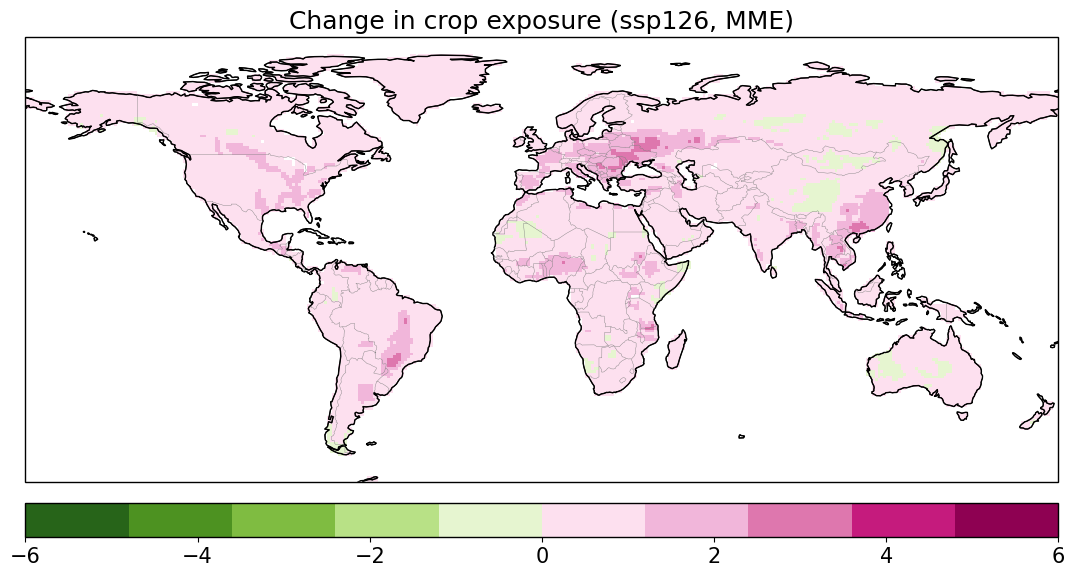

In [13]:
plot_exposure(mmes['ssp126'], vmin=-6, vmax=6, cmap=cmaps.piyg_10_r, title="Change in crop exposure (ssp126, MME)")

## All SSPs

Some auxiliary functions:

In [14]:
# ============================================================
# formatting helpers for relative (%) vs. absolute panels
# ============================================================
def _fold_change_formatter(value, _pos=None):
    """Turn a %-change value (e.g. 400, meaning +400%) into a fold-change
    label (e.g. '×5'). Floors at ×0 since a relative change can't go below
    -100% (you can't lose more than everything you started with) -- so
    every value <= -100% collapses to the same '×0' label. That's the
    tradeoff of this style: it reads intuitively near 0, but throws away
    resolution on the negative side of a wide colorbar like panel A's
    (vmin=-1000). Percent style keeps that resolution; pick per panel.
    """
    fold = max(1 + value / 100.0, 0.0)
    return f"×{fold:g}"


def _format_edge_label(value, anom_type, relative_style):
    if anom_type == "relative":
        return _fold_change_formatter(value) if relative_style == "fold" else f"{value:.0f}%"
    return f"{value:.3g}"


# ============================================================
# 4. plotting helper
# ============================================================
def plot_panel(ax, plot_grid, title, vmin, vmax, cmap, extend="max", label="",
                anom_type="absolute", relative_style="percent"):
    """
    anom_type : "absolute" or "relative"
        "absolute": behaves exactly like the original function -- plain
        numeric ticks, title suffixed with `unit` (e.g. "mm day-1").
        "relative": `plot_grid` is assumed to already be a %-change (i.e.
        multiplied by 100 upstream, as frequency/intensity/duration are
        here). Colorbar + histogram ticks are relabeled as percent (default)
        or, if relative_style="fold", as a fold-change like "×5". The title
        is suffixed with "[% change]" instead of `unit`, so a physical unit
        never gets attached to a relative quantity by mistake -- this was
        the actual bug in panels A-C of the original figure (titled
        "event/year", "mm/day", "days/event" while plotting %-change data).
    relative_style : "percent" or "fold", only used when anom_type="relative".
    """
    if anom_type not in ("absolute", "relative"):
        raise ValueError("anom_type must be 'absolute' or 'relative'")

    LON, LAT = plot_grid.lon.values, plot_grid.lat.values
    plot_grid = plot_grid.values
    im = ax.pcolormesh(
        LON, LAT, plot_grid,
        cmap=cmap,
        transform=ccrs.PlateCarree(),
        vmin=vmin,
        vmax=vmax
    )

    ax.set_extent([-180, 180, -65, 90], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.OCEAN, color="0.9", zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, color="black")
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, color="gray")
    ax.coastlines(linewidth=1.5)
    ax.text(
        0.02, 1.05, label,
        transform=ax.transAxes,
        fontsize=25,
        fontweight='bold',
        va='top',
        ha='left'
    )
    # ========================================================
    # inset colorbar
    # ========================================================
    cax = inset_axes(
        ax,
        width="35%",
        height="3%",
        loc='lower center',
        bbox_to_anchor=(0.15, 0.08, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0
    )

    cb = plt.colorbar(
        im,
        cax=cax,
        orientation="horizontal",
        extend=extend
    )

    # FIX: this is the actual "-100% / ×10 instead of a bare number" ask.
    if anom_type == "relative":
        if relative_style == "fold":
            cb.ax.xaxis.set_major_formatter(FuncFormatter(_fold_change_formatter))
        else:
            cb.ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
    # anom_type == "absolute": leave the default numeric formatter as-is

    cb.ax.tick_params(labelsize=12)
    cb.ax.xaxis.set_label_position('top')
    cb.ax.xaxis.set_ticks_position('bottom')
    cb.outline.set_linewidth(1)
    cb.outline.set_edgecolor("black")
    cax.patch.set_alpha(0.8)

    ax.set_title(title, fontsize=20)

    # ========================================================
    # inset histogram (area-weighted)
    # ========================================================
    if np.ndim(LAT) == 1:
        lat2d = np.repeat(LAT[:, None], plot_grid.shape[1], axis=1)
    else:
        lat2d = LAT

    weights = np.cos(np.deg2rad(lat2d))

    # FIX: the next three lines were duplicated verbatim right below
    # themselves in the original (no effect on the result, just wasted
    # cycles) -- removed the redundant copy.
    valid_mask = np.isfinite(plot_grid) & np.isfinite(weights)
    valid_data = plot_grid[valid_mask].flatten()
    valid_weights = weights[valid_mask].flatten()

    # Don't drop out-of-range values -- clip them into the edge bins instead
    global_mean = np.sum(valid_data * valid_weights) / np.sum(valid_weights)
    weighted_squared_diff = np.sum(valid_weights * (valid_data - global_mean) ** 2) / np.sum(valid_weights)
    global_std = np.sqrt(weighted_squared_diff)
    valid_data = np.clip(valid_data, vmin, vmax)

    if len(valid_data) > 0:
        normalized_weights = valid_weights / np.sum(valid_weights)

        inset_ax = inset_axes(
            ax,
            width="12%",
            height="15%",
            loc="lower left",
            bbox_to_anchor=(0.1, 0.155, 1.1, 1.3),
            bbox_transform=ax.transAxes
        )

        bins = np.linspace(vmin, vmax, 22)

        hist_vals, bin_edges, patches = inset_ax.hist(
            valid_data,
            bins=bins,
            weights=normalized_weights,
            density=True,
            edgecolor="black",
            linewidth=1.2
        )

        norm = plt.Normalize(vmin=vmin, vmax=vmax)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        for patch, center in zip(patches, bin_centers):
            patch.set_facecolor(cmap(norm(center)))

        inset_ax.tick_params(labelsize=9)
        inset_ax.get_yaxis().set_visible(False)

        for spine in inset_ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.2)
            spine.set_color("gray")
            spine.set_alpha(0.5)

        inset_ax.set_xlim(vmin, vmax)
        xticks = np.linspace(vmin, vmax, 3)  # left, center, right
        inset_ax.set_xticks(xticks)

        # FIX: the mu/sigma box stays in percent even when
        # relative_style="fold" -- the mean/stdev of a fold-change isn't a
        # standard, easily-interpreted quantity, so the summary stats stay
        # in % and the x5-style fold labels are reserved for the tick marks.
        mean_str = f"{global_mean:.4g}%" if anom_type == "relative" else f"{global_mean:0.4g}"
        std_str = f"{global_std:.4g}%" if anom_type == "relative" else f"{global_std:0.4g}"
        formatted_mean = mean_str.replace("-", "−")
        formatted_std = std_str.replace("-", "−")
        inset_ax.set_facecolor("0.9")
        inset_ax.set_title(
            f"μ = {formatted_mean}\nσ = {formatted_std}",
            fontsize=12,
            ha="left",
            x=0
        )
        xtick_labels = [
            _format_edge_label(vmin, anom_type, relative_style),
            _format_edge_label(xticks[1], anom_type, relative_style),
            ">" + _format_edge_label(vmax, anom_type, relative_style),
        ]
        inset_ax.set_xticklabels(xtick_labels)
    ax.gridlines(
        draw_labels=False,
        linewidth=0.4,
        color="gray",
        alpha=0.5,
        linestyle="--"
    )

    return im


/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/tmp

  ✓ crop_exposure_anomaly.png
  ✓ crop_exposure_anomaly.pdf


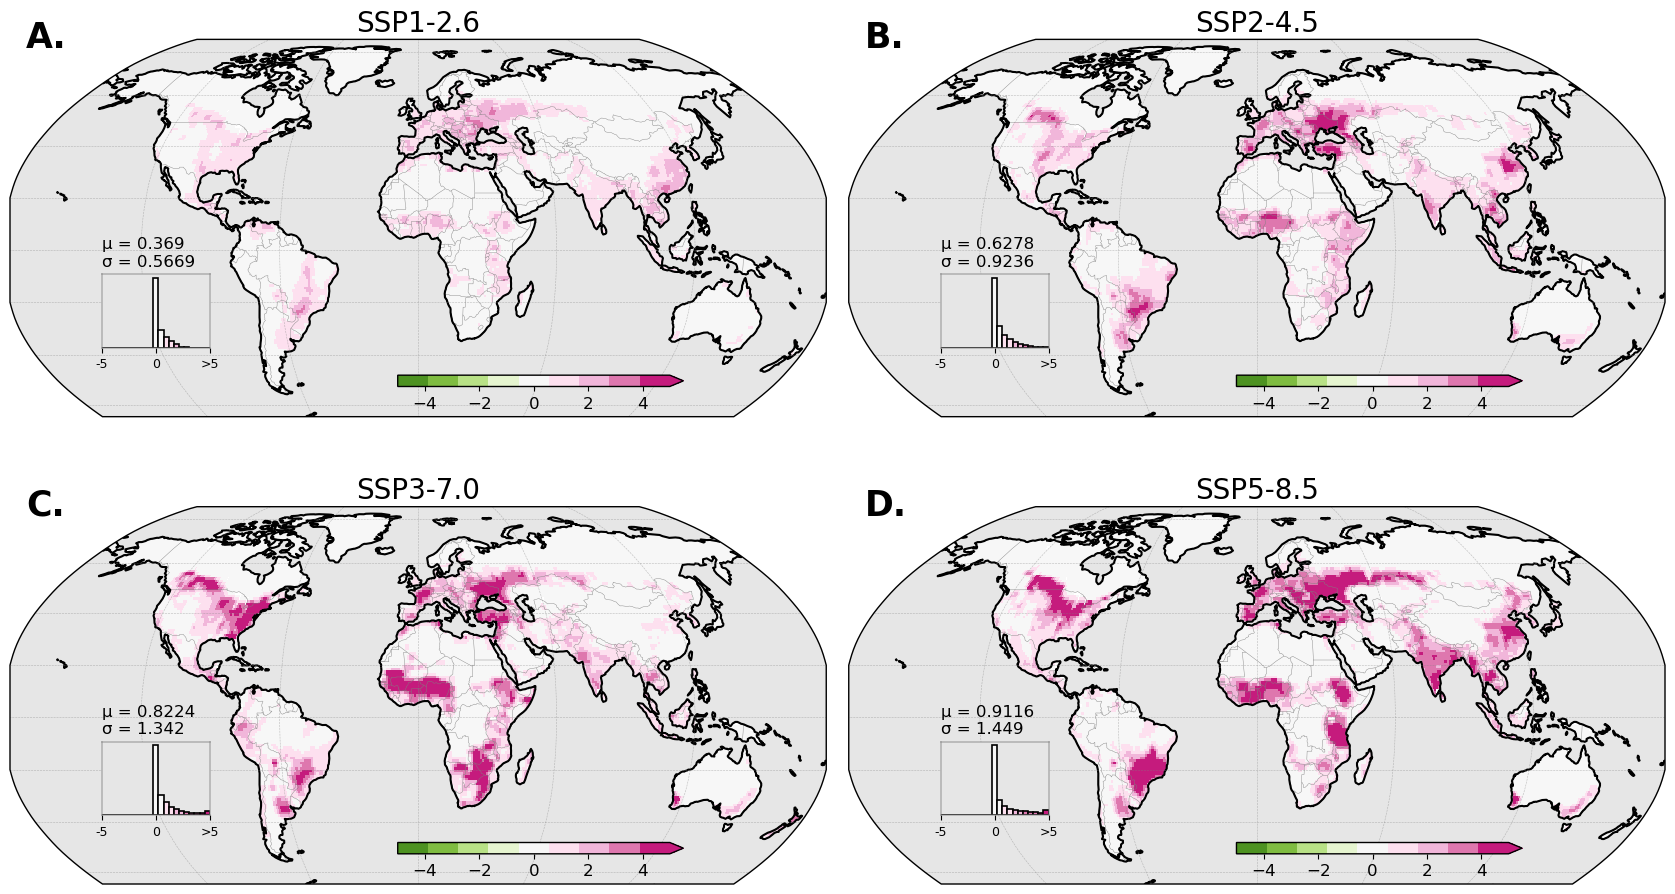

In [16]:
#  2x2 subplot
fig, axes = plt.subplots(
    2, 2,
    figsize=(17, 10),
    subplot_kw={"projection": ccrs.Robinson()}
)

axes = axes.flatten()

VMIN = -5
VMAX = 5
CMAP = cmaps.piyg_r

# panel A. SSP1-2.6
plot_panel(
    axes[0],
    mmes['ssp126'],
    r"SSP1-2.6",
    vmin=VMIN,
    vmax=VMAX,
    cmap=CMAP,
    extend="max", 
    label="A.",
    anom_type="absolute",
)

# panel B. SSP2-4.5
plot_panel(
    axes[1],
    mmes['ssp245'],
    r"SSP2-4.5",
    vmin=VMIN,
    vmax=VMAX,
    cmap=CMAP,
    extend="max", 
    label="B.",
    anom_type="absolute",
)

# panel C. SSP3-7.0
plot_panel(
    axes[2],
    mmes['ssp370'],
    r"SSP3-7.0",
    vmin=VMIN,
    vmax=VMAX,
    cmap=CMAP,
    extend="max", 
    label="C.",
    anom_type="absolute",
)

# panel C. SSP5-8.5
plot_panel(
    axes[3],
    mmes['ssp585'],
    r"SSP5-8.5",
    vmin=VMIN,
    vmax=VMAX,
    cmap=CMAP,
    extend="max", 
    label="D.",
    anom_type="absolute",
)

plt.tight_layout()

# Save in current directory as png and pdf
for ext in ["png", "pdf"]:
        filename = f"crop_exposure_anomaly.{ext}"
        fig.savefig(filename, dpi=500, bbox_inches="tight", pad_inches=0.3)
        print(f"  ✓ {filename}")

plt.show()
